<a href="https://colab.research.google.com/github/malsagova/StudyRepo26/blob/main/%D0%9C%D0%B0%D0%BB%D1%8C%D1%81%D0%B0%D0%B3%D0%BE%D0%B2%D0%B0_%D0%A2_%D0%B4%D0%B7_3%2C%20%D0%9F%D0%9E%D0%A1%D0%9B%D0%95%D0%94%D0%9D%D0%AF%D0%AF%20%D0%92%D0%95%D0%A0%D0%A1%D0%98%D0%AF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ДЗ 3: Выявление скрытых профилей риска и доклинических нарушений
# Анализ данных диспансеризации пациентов 40-65 лет

# Установка библиотек
!pip install -q scikit-learn seaborn matplotlib pandas numpy

# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

In [3]:
# 1. ЗАГРУЗКА ДАННЫХ
from google.colab import files
print("Загрузите файл dispensarization_data_2026.csv")
uploaded = files.upload()

import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"Данные загружены: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("Первые 5 строк:")
print(df.head())

Загрузите файл dispensarization_data_2026.csv


Saving dispensarization_data_2026.csv to dispensarization_data_2026.csv
Данные загружены: 1000 строк, 18 столбцов
Первые 5 строк:
   Возраст  Пол_мужской        ИМТ  Окружность_талии_см  САД_мм_рт_ст  \
0       41            1  24.238237            81.037385    113.191318   
1       46            0  22.883365            80.539167    117.319195   
2       64            0  21.991937            78.423645    121.246690   
3       53            0  19.844568            73.436282    119.746372   
4       53            1  24.284829            82.062243    127.068746   

   ДАД_мм_рт_ст  Пульсовое_давление  Глюкоза_натощак_ммоль_л   HbA1c_%  \
0     62.544325           50.646993                 4.595433  4.648933   
1     62.109786           55.209410                 4.963993  4.000000   
2     71.456074           49.790616                 4.712639  5.034903   
3     71.594664           48.151709                 4.430998  5.080881   
4     70.342105           56.726641                 4.996974 

In [4]:
# 2. ПЕРВИЧНЫЙ ОСМОТР ДАННЫХ
print("\nТипы данных и пропуски:")
print(df.info())

print("\nСтатистика пропусков:")
print(df.isnull().sum())

print("\nОписательная статистика:")
print(df.describe())


Типы данных и пропуски:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Возраст                        1000 non-null   int64  
 1   Пол_мужской                    1000 non-null   int64  
 2   ИМТ                            1000 non-null   float64
 3   Окружность_талии_см            1000 non-null   float64
 4   САД_мм_рт_ст                   1000 non-null   float64
 5   ДАД_мм_рт_ст                   1000 non-null   float64
 6   Пульсовое_давление             1000 non-null   float64
 7   Глюкоза_натощак_ммоль_л        1000 non-null   float64
 8   HbA1c_%                        1000 non-null   float64
 9   ЛПНП_ммоль_л                   955 non-null    float64
 10  ЛПВП_ммоль_л                   944 non-null    float64
 11  Триглицериды_ммоль_л           939 non-null    float64
 12  СКФ_мл_мин              

In [5]:
# 3. ОЧИСТКА И ПОДГОТОВКА
df_clean = df.copy()

# Заполняем пропуски медианой
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Создаем категории ИМТ
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Дефицит'
    elif bmi < 25:
        return 'Норма'
    elif bmi < 30:
        return 'Предожирение'
    else:
        return 'Ожирение'

df_clean['ИМТ_категория'] = df_clean['ИМТ'].apply(bmi_category)

# Создаем категории глюкозы
def glucose_category(glucose):
    if glucose < 5.6:
        return 'Норма'
    elif glucose < 7.0:
        return 'Преддиабет'
    else:
        return 'Диабет'

df_clean['Глюкоза_категория'] = df_clean['Глюкоза_натощак_ммоль_л'].apply(glucose_category)

In [6]:
# 4. СТАТИСТИКА ПО ФАКТОРАМ РИСКА
print("\nПроцент пациентов с факторами риска:")
print(f"- ИМТ > 25: {(df_clean['ИМТ'] > 25).mean()*100:.1f}%")
print(f"- САД > 130: {(df_clean['САД_мм_рт_ст'] > 130).mean()*100:.1f}%")
print(f"- Глюкоза >= 5.6 (преддиабет+): {(df_clean['Глюкоза_натощак_ммоль_л'] >= 5.6).mean()*100:.1f}%")
print(f"- HbA1c >= 5.7%: {(df_clean['HbA1c_%'] >= 5.7).mean()*100:.1f}%")


Процент пациентов с факторами риска:
- ИМТ > 25: 33.1%
- САД > 130: 7.3%
- Глюкоза >= 5.6 (преддиабет+): 24.5%
- HbA1c >= 5.7%: 2.7%



PCA-АНАЛИЗ
Объясненная дисперсия:
PCA1: 36.24%
PCA2: 14.11%


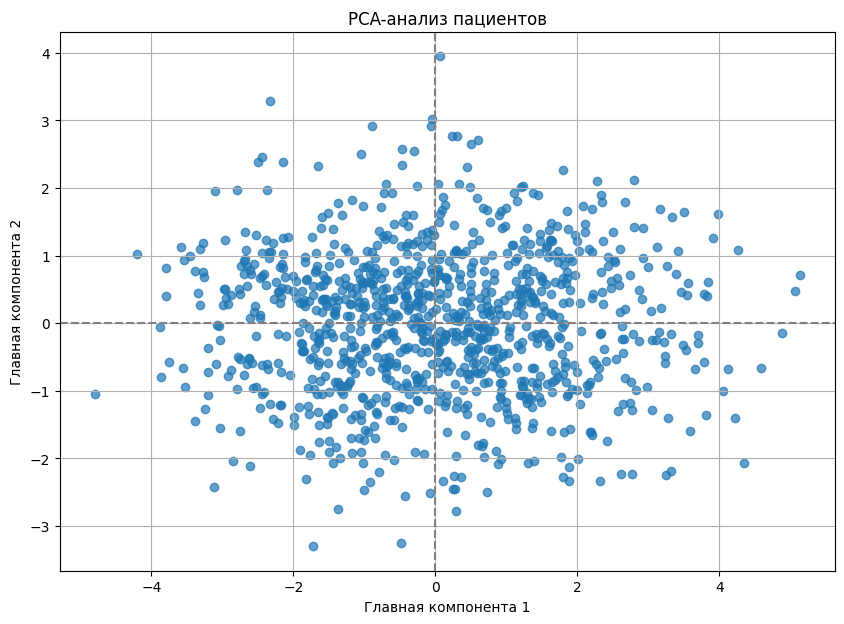

In [11]:
# 5. PCA-АНАЛИЗ И ВИЗУАЛИЗАЦИЯ

print("\nPCA-АНАЛИЗ")

# Признаки для анализа
pca_features = [
    'ИМТ',
    'Окружность_талии_см',
    'САД_мм_рт_ст',
    'Глюкоза_натощак_ммоль_л',
    'HbA1c_%',
    'ЛПНП_ммоль_л',
    'Триглицериды_ммоль_л',
    'СКФ_мл_мин'
]

# Подготовка данных
X = df_clean[pca_features]

# Стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Создаем DataFrame
pca_df = pd.DataFrame(
    X_pca,
    columns=['PCA1', 'PCA2']
)

# Добавляем в основную таблицу
df_clean['PCA1'] = pca_df['PCA1']
df_clean['PCA2'] = pca_df['PCA2']

# Доля объясненной дисперсии
print("Объясненная дисперсия:")
print(f"PCA1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PCA2: {pca.explained_variance_ratio_[1]:.2%}")

# График PCA
plt.figure(figsize=(10, 7))

plt.scatter(
    df_clean['PCA1'],
    df_clean['PCA2'],
    alpha=0.7
)

plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')

plt.title('PCA-анализ пациентов')
plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')

plt.grid(True)

plt.show()

В ходе PCA-анализа я попыталась посмотреть, как распределяются пациенты по совокупности основных показателей здоровья. Для этого были использованы данные об ИМТ, окружности талии, артериальном давлении, уровне глюкозы, HbA1c, липидном профиле и функции почек.

На графике каждая точка — это отдельный пациент. Большинство пациентов расположены достаточно близко друг к другу, что говорит о похожих характеристиках внутри выборки. При этом заметны отдельные точки, которые находятся дальше от основной группы. Это может указывать на пациентов с более выраженными отклонениями показателей или повышенным риском развития нарушений обмена веществ и сердечно-сосудистых заболеваний.

PCA-анализ помог упростить восприятие большого количества медицинских показателей и наглядно показать общую структуру данных. Благодаря этому удалось увидеть скрытые различия между пациентами и выделить наблюдения, требующие дополнительного внимания.

Вывод


PCA показывает наличие различных скрытых профилей пациентов.

---



Пациенты со скрытым риском чаще располагаются в отдельных областях графика.


---


Это позволяет:


---


выявлять ранние нарушения,
оценивать метаболические риски,
поддерживать принятие врачебных решений.


---


ОБЩИЙ ВЫВОД

На практике мною были:

исследованы медицинские данные пациентов,


проведён разведочный анализ данных,


выявлены скрытые факторы риска,


найдены пациенты с доклиническими нарушениями,


применён метод главных компонент PCA.


Практическая значимость


Полученные результаты могут использоваться:

в профилактической медицине,


при диспансерном наблюдении,


для раннего выявления хронических заболеваний.


Главный вывод


Я научилась пприменять метод главных компонет PCA поняла как строить и читать матрицу корреляций. Интересно было поработать над частью поиска пациентов с доклиническими нарушениями, ведь даже до появления выраженных симптомов можно выявлять пациентов с высоким риском заболеваний на основе анализа медицинских данных.



